[OK] Figure performance sauvegardée : r_paper/figures/perf_mva.png
[OK] Figure temps sauvegardée : r_paper/figures/time_mva.png


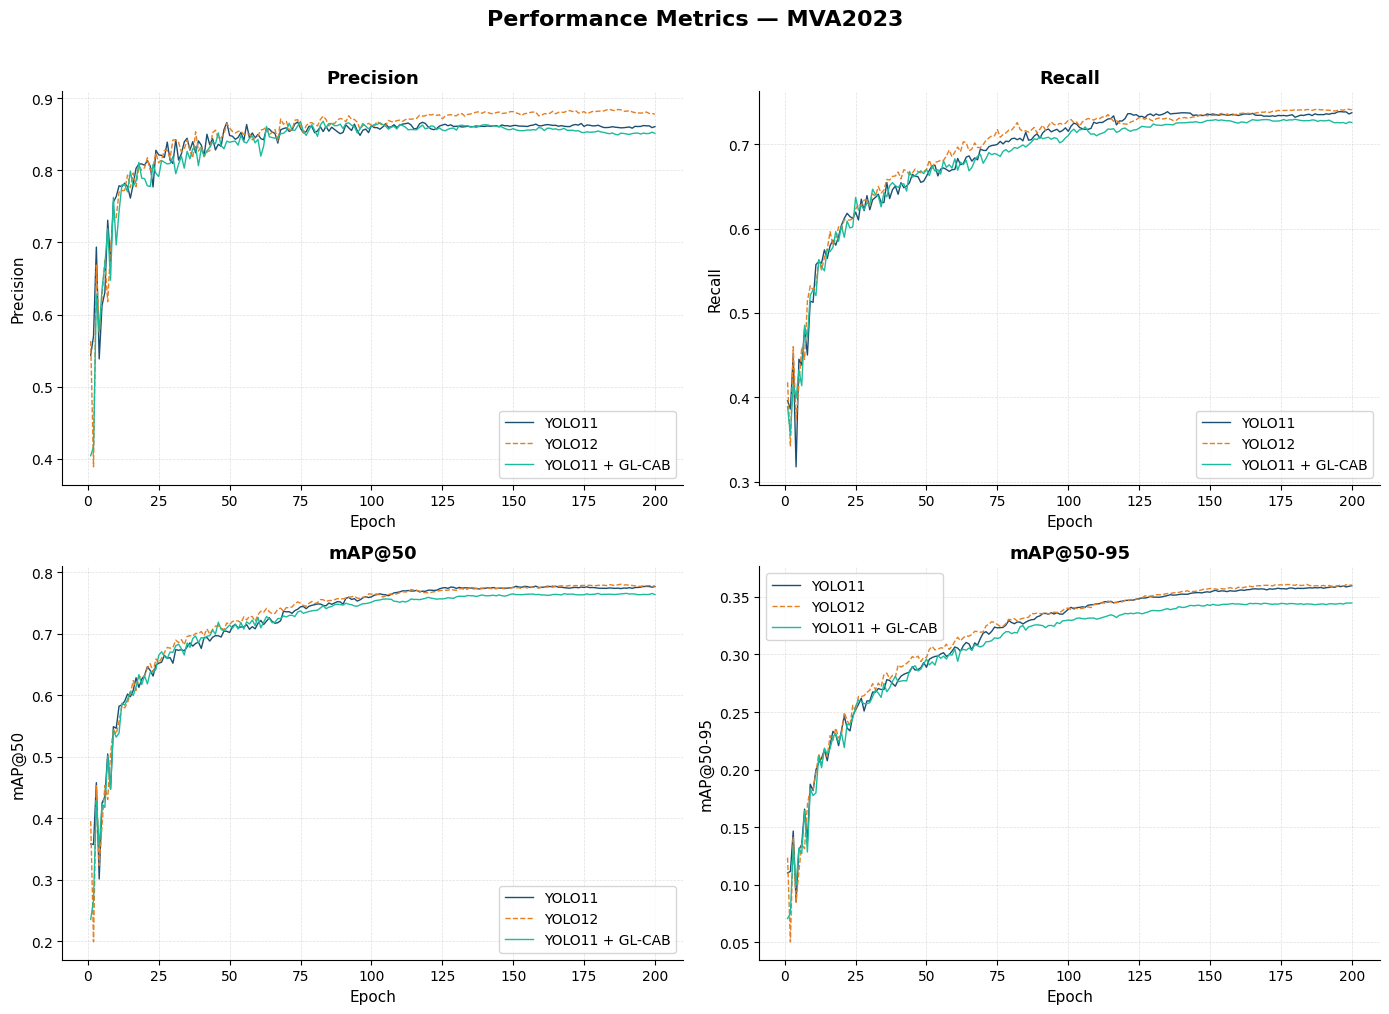

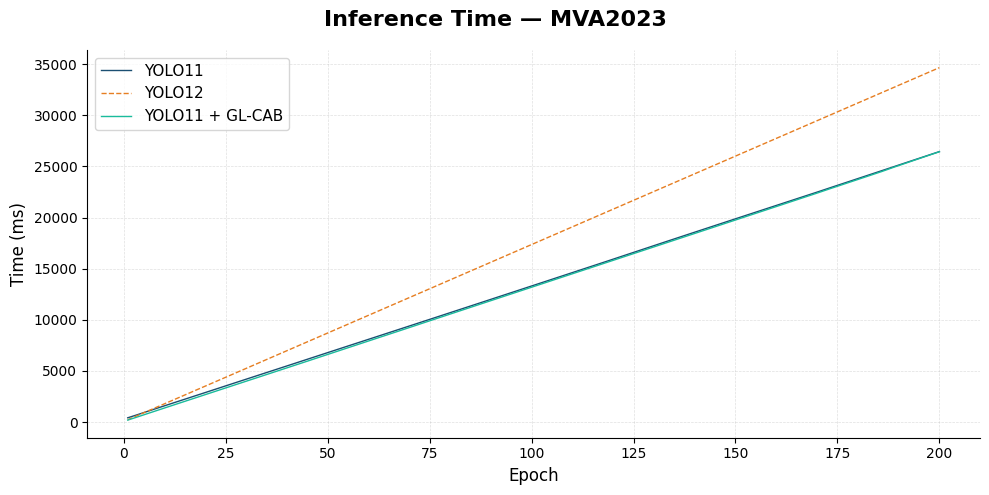

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import os


# ─────────────────────────────────────────────────────────────────────────────
# Configuration
# ─────────────────────────────────────────────────────────────────────────────

# Mapping dataset code → préfixe de fichier CSV
DATASET_FILES = {
    "vd":  ("vd11.csv",  "vd12.csv",  "vdGL.csv"),
    #"dt":  ("dt11.csv",  "dt12.csv",  "dtGL.csv"),
    "mva": ("mva11.csv", "mva12.csv", "mvaGL.csv"),
}

DATASET_LABELS = {
    "vd":  "VisDrone2019",
    #"dt":  "DOTA v1.5",
    "mva": "MVA2023",
}

MODEL_LABELS = ["YOLO11", "YOLO12", "YOLO11 + GL-CAB"]
MODEL_COLORS = ["#1B4F72", "#E67E22", "#1ABC9C"]   # bleu, orange, vert
MODEL_STYLES = ["-",       "--",      "-"]
MODEL_WIDTHS = [1,        1,       1]

# Métriques du panel 2×2
PERF_METRICS = [
    "metrics/precision(B)",
    "metrics/recall(B)",
    "metrics/mAP50(B)",
    "metrics/mAP50-95(B)",
]
PERF_TITLES = ["Precision", "Recall", "mAP@50", "mAP@50-95"]

# Colonne temps
TIME_METRIC = "time"


# ─────────────────────────────────────────────────────────────────────────────
# Fonction principale
# ─────────────────────────────────────────────────────────────────────────────

def plot_comparison(dataset: str, data_dir: str = ".", save_dir: str = "."):
    """
    Génère deux figures de comparaison des modèles YOLO11 / YOLO12 / YOLO11+GL-CAB
    pour un dataset donné.

    Parameters
    ----------
    dataset  : str
        Code du dataset : "vd" (VisDrone), "dt" (DOTA), "mva" (MVA2023).
    data_dir : str
        Dossier contenant les fichiers CSV.
    save_dir : str
        Dossier où sauvegarder les figures produites.

    Returns
    -------
    fig_perf : matplotlib.figure.Figure
        Figure 2×2 des 4 métriques de performance.
    fig_time : matplotlib.figure.Figure
        Figure de la métrique temps.
    """

    if dataset not in DATASET_FILES:
        raise ValueError(
            f"Dataset '{dataset}' inconnu. Choisir parmi : {list(DATASET_FILES)}"
        )

    dataset_label = DATASET_LABELS[dataset]
    files = DATASET_FILES[dataset]

    # ── Chargement des données ──────────────────────────────────────────────
    dfs = []
    for fname in files:
        path = os.path.join(data_dir, fname)
        dfs.append(pd.read_csv(path))

    # ── Figure 1 : panel 2×2 des métriques de performance ──────────────────
    fig_perf, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig_perf.suptitle(
        f"Performance Metrics — {dataset_label}",
        fontsize=16, fontweight="bold", y=1.01
    )
    axes = axes.flatten()

    for ax, metric, title in zip(axes, PERF_METRICS, PERF_TITLES):
        for df, label, color, ls, lw in zip(
            dfs, MODEL_LABELS, MODEL_COLORS, MODEL_STYLES, MODEL_WIDTHS
        ):
            if metric in df.columns:
                epochs = df.iloc[:, 0]
                ax.plot(epochs, df[metric],
                        label=label, color=color,
                        linestyle=ls, linewidth=lw)
            else:
                print(f"[WARN] Colonne '{metric}' absente dans {label} — ignorée.")

        ax.set_title(title, fontsize=13, fontweight="bold")
        ax.set_xlabel("Epoch", fontsize=11)
        ax.set_ylabel(title, fontsize=11)
        ax.legend(fontsize=10)
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()

    path_perf = os.path.join(save_dir, f"perf_{dataset}.png")
    fig_perf.savefig(path_perf, dpi=150, bbox_inches="tight")
    print(f"[OK] Figure performance sauvegardée : {path_perf}")

    # ── Figure 2 : métrique temps ───────────────────────────────────────────
    fig_time, ax_time = plt.subplots(figsize=(10, 5))
    fig_time.suptitle(
        f"Inference Time — {dataset_label}",
        fontsize=16, fontweight="bold"
    )

    for df, label, color, ls, lw in zip(
        dfs, MODEL_LABELS, MODEL_COLORS, MODEL_STYLES, MODEL_WIDTHS
    ):
        if TIME_METRIC in df.columns:
            epochs = df.iloc[:, 0]
            ax_time.plot(epochs, df[TIME_METRIC],
                         label=label, color=color,
                         linestyle=ls, linewidth=lw)
        else:
            print(f"[WARN] Colonne '{TIME_METRIC}' absente dans {label} — ignorée.")

    ax_time.set_xlabel("Epoch", fontsize=12)
    ax_time.set_ylabel("Time (ms)", fontsize=12)
    ax_time.legend(fontsize=11)
    ax_time.grid(True, linestyle="--", alpha=0.4)
    ax_time.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()

    path_time = os.path.join(save_dir, f"time_{dataset}.png")
    fig_time.savefig(path_time, dpi=150, bbox_inches="tight")
    print(f"[OK] Figure temps sauvegardée : {path_time}")

    return fig_perf, fig_time


# ─────────────────────────────────────────────────────────────────────────────
# Exemple d'utilisation
# ─────────────────────────────────────────────────────────────────────────────

if __name__ == "__main__":
    # Générer les figures pour VisDrone
    fig_perf, fig_time = plot_comparison(
        dataset="mva",
        data_dir="r_paper",     # dossier contenant vd11.csv, vd12.csv, vdGL.csv
        save_dir="r_paper/figures",   # dossier de sortie
    )
    plt.show()

    # Décommenter pour les autres datasets :
    # plot_comparison("dt",  data_dir="rs600", save_dir="figures")
    # plot_comparison("mva", data_dir="rs600", save_dir="figures")